![Quantyma Research](logo.png)

**Title:** Resilience Analysis of Recurrent Neural Networks in Predicting High-Turbulence Chaotic Systems under Stochastic Noise  
**Author:** Bruno Priantti  
**Institution:** Quantyma Research  
**Date:** April 2026  
**License:** MIT License  
 
**Content:**   
This notebook implements the experimental framework for evaluating the predictive resilience of 
Recurrent Neural Networks (RNN, GRU, and LSTM) under high-turbulence conditions.
We use the Lorenz-63 system with a 20% additive Gaussian noise to simulate realistic 
observational uncertainty and assess topological preservation.

### imports

In [1]:
from methods import *

import time
import numpy as np
import pandas as pd

### experiment config:

In [19]:
exp_config = ExperimentConfig(n_steps=11000, 
                              dt=0.01, 
                              sigma=12.96, 
                              rho=99.96, 
                              beta=8/3,
                              warmup=1000,
                              noise_level=0.20,
                              seed=42,
                              input_window=100,
                              n_epochs = 20,
                              batch_size = 128,
                              lr=1e-3,
                              ) 

logger = ExperimentLogger(exp_config)

experiment registered em: experiments/20260423_1457_efd11dea


### generate database:

In [20]:
df = get_lorentz_63_dataframe(n_steps=exp_config.n_steps, dt=exp_config.dt, sigma=exp_config.sigma, rho=exp_config.rho, beta=exp_config.beta, warmup=exp_config.warmup)
df_noisy = add_noise_to_dataframe(df, noise_level=exp_config.noise_level, seed=exp_config.seed)

### database visualization:

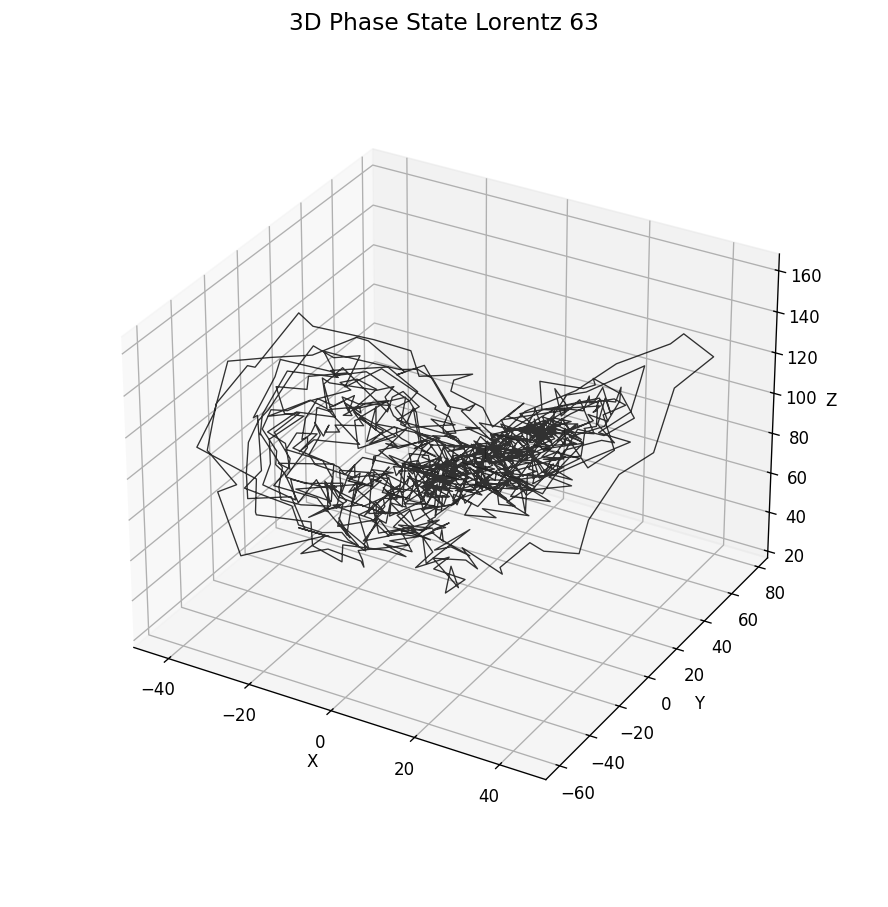

In [21]:
plot_lorenz_3d(df_noisy, steps=1000, title="3D Phase State Lorentz 63", save_path=f"{logger.path}/plots/lorentz_3d.png")

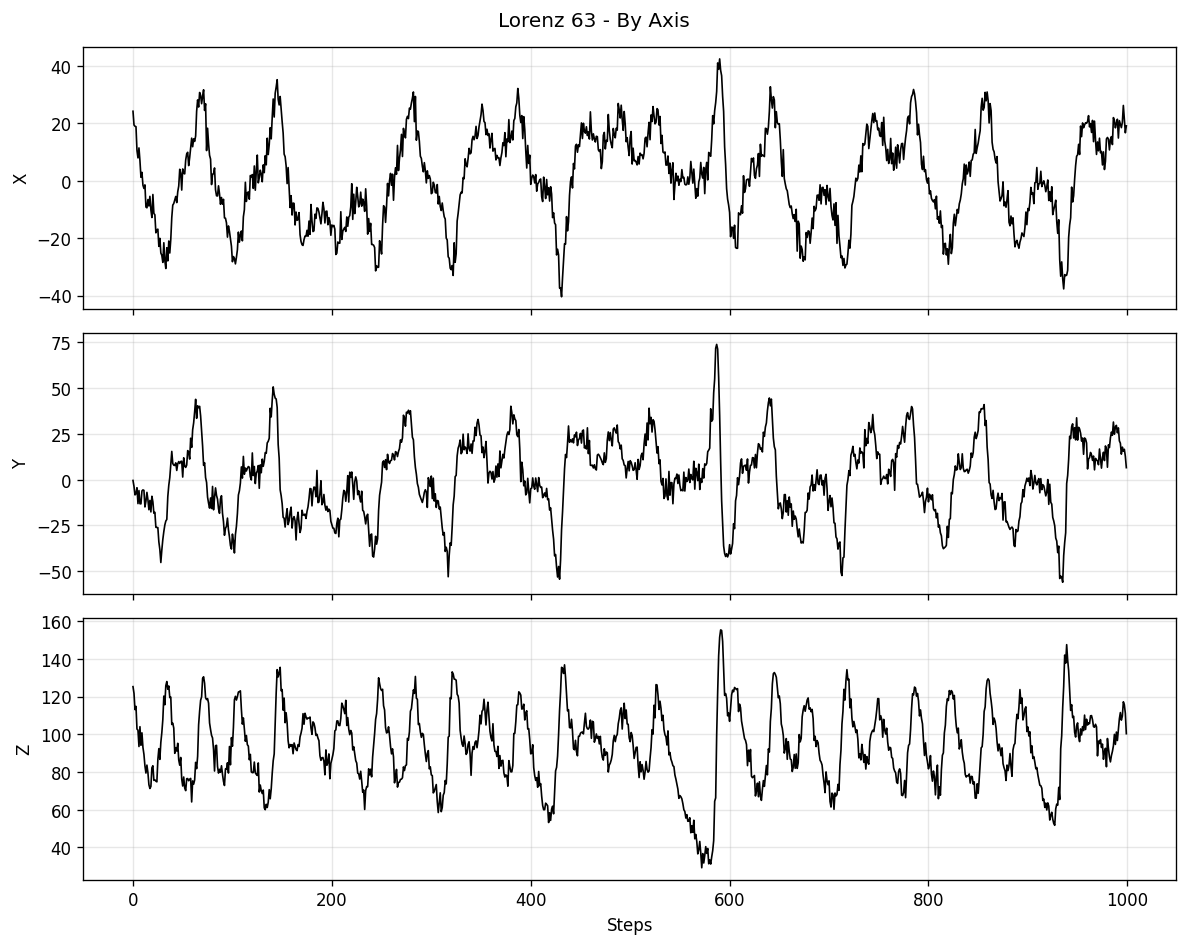

In [22]:
plot_axes_timeseries(df_noisy, steps=1000, title="Lorenz 63 - By Axis", save_path=f"{logger.path}/plots/axes_timeseries.png")

### split train, val, test:

In [23]:
from sklearn.model_selection import train_test_split

train, holdout = train_test_split(df_noisy, test_size=0.30, shuffle=False)
val, test = train_test_split(holdout, test_size=0.5, shuffle=False)
print(train.shape, val.shape, test.shape)

(7000, 3) (1500, 3) (1500, 3)


### pre processing:

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1,1))

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)
val_scaled = scaler.transform(val)

train_scaled = pd.DataFrame(train_scaled, columns=["x", "y", "z"])
test_scaled = pd.DataFrame(test_scaled, columns=["x", "y", "z"])
val_scaled = pd.DataFrame(val_scaled, columns=["x", "y", "z"])

### x and y split:

In [25]:
train_research = generate_XY(train_scaled, input_window=exp_config.input_window, output_window=1)
val_research = generate_XY(val_scaled, input_window=exp_config.input_window, output_window=1)
test_research = generate_XY(test_scaled, input_window=exp_config.input_window, output_window=1)

X_train = np.array([v["X"] for v in train_research.values()])
Y_train = np.array([v["Y"] for v in train_research.values()])

X_val = np.array([v["X"] for v in val_research.values()])
Y_val = np.array([v["Y"] for v in val_research.values()])

X_test = np.array([v["X"] for v in test_research.values()])
Y_test = np.array([v["Y"] for v in test_research.values()])

### modeling:

In [26]:
exp = ModelingExperimentRegression()

torch.manual_seed(exp_config.seed)
torch.cuda.manual_seed_all(exp_config.seed)
torch.backends.cudnn.deterministic = True

In [27]:
import torch

X_train_tensor = torch.tensor(X_train).float()
Y_train_tensor = torch.tensor(Y_train).float().squeeze(1)

X_val_tensor = torch.tensor(X_val).float()
Y_val_tensor = torch.tensor(Y_val).float().squeeze(1)

X_test_tensor = torch.tensor(X_test).float()
Y_test_tensor = torch.tensor(Y_test).float().squeeze(1)

#### RNN:

In [28]:
model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=exp_config.lr)


X_batches = torch.split(X_train_tensor, exp_config.batch_size)
Y_batches = torch.split(Y_train_tensor, exp_config.batch_size)


train_loss_history = []
val_loss_history = []


start_time = time.time() 
for epoch in range(exp_config.n_epochs):
    model.train()
    epoch_losses = []
    for x_b, y_b in zip(X_batches, Y_batches):
        optimizer.zero_grad()
        pred = model(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, Y_val_tensor)

    train_loss_mean = sum(epoch_losses) / len(epoch_losses)
    train_loss_history.append(train_loss_mean)
    val_loss_history.append(val_loss.item())
    print(f"Epoch {epoch:02d} | Train: {train_loss_mean:.6f} | Val: {val_loss.item():.6f}")
training_time = time.time() - start_time


model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_val = model(X_val_tensor)
    y_pred_test = model(X_test_tensor)


exp.save(
    name="RNN",
    y_train=scaler.inverse_transform(Y_train_tensor.numpy()),
    y_val=scaler.inverse_transform(Y_val_tensor.numpy()),
    y_test=scaler.inverse_transform(Y_test_tensor.numpy()),    
    y_pred_train=scaler.inverse_transform(y_pred_train.detach().numpy()),
    y_pred_val=scaler.inverse_transform(y_pred_val.detach().numpy()),
    y_pred_test=scaler.inverse_transform(y_pred_test.detach().numpy()),
    loss_history={"train": train_loss_history, "val": val_loss_history},
    training_time=training_time
)

Epoch 00 | Train: 0.038776 | Val: 0.012058
Epoch 01 | Train: 0.009121 | Val: 0.007822
Epoch 02 | Train: 0.007307 | Val: 0.007296
Epoch 03 | Train: 0.006885 | Val: 0.007054
Epoch 04 | Train: 0.006606 | Val: 0.006820
Epoch 05 | Train: 0.006341 | Val: 0.006590
Epoch 06 | Train: 0.006029 | Val: 0.006211
Epoch 07 | Train: 0.005680 | Val: 0.005663
Epoch 08 | Train: 0.005517 | Val: 0.005493
Epoch 09 | Train: 0.005292 | Val: 0.005409
Epoch 10 | Train: 0.005271 | Val: 0.005275
Epoch 11 | Train: 0.005116 | Val: 0.005219
Epoch 12 | Train: 0.005123 | Val: 0.005151
Epoch 13 | Train: 0.005053 | Val: 0.005118
Epoch 14 | Train: 0.004992 | Val: 0.005080
Epoch 15 | Train: 0.004986 | Val: 0.005063
Epoch 16 | Train: 0.004929 | Val: 0.005030
Epoch 17 | Train: 0.004928 | Val: 0.005018
Epoch 18 | Train: 0.004883 | Val: 0.004988
Epoch 19 | Train: 0.004877 | Val: 0.004974


#### GRU

In [29]:
model = GRU()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=exp_config.lr)


X_batches = torch.split(X_train_tensor, exp_config.batch_size)
Y_batches = torch.split(Y_train_tensor, exp_config.batch_size)


train_loss_history = []
val_loss_history = []


start_time = time.time() 
for epoch in range(exp_config.n_epochs):
    model.train()
    epoch_losses = []
    for x_b, y_b in zip(X_batches, Y_batches):
        optimizer.zero_grad()
        pred = model(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, Y_val_tensor)

    train_loss_mean = sum(epoch_losses) / len(epoch_losses)
    train_loss_history.append(train_loss_mean)
    val_loss_history.append(val_loss.item())
    print(f"Epoch {epoch:02d} | Train: {train_loss_mean:.6f} | Val: {val_loss.item():.6f}")
training_time = time.time() - start_time


model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_val = model(X_val_tensor)
    y_pred_test = model(X_test_tensor)


exp.save(
    name="GRU",
    y_train=scaler.inverse_transform(Y_train_tensor.numpy()),
    y_val=scaler.inverse_transform(Y_val_tensor.numpy()),
    y_test=scaler.inverse_transform(Y_test_tensor.numpy()),    
    y_pred_train=scaler.inverse_transform(y_pred_train.detach().numpy()),
    y_pred_val=scaler.inverse_transform(y_pred_val.detach().numpy()),
    y_pred_test=scaler.inverse_transform(y_pred_test.detach().numpy()),
    loss_history={"train": train_loss_history, "val": val_loss_history},
    training_time=training_time
)

Epoch 00 | Train: 0.059287 | Val: 0.022948
Epoch 01 | Train: 0.013538 | Val: 0.007359
Epoch 02 | Train: 0.005741 | Val: 0.005371
Epoch 03 | Train: 0.004963 | Val: 0.005149
Epoch 04 | Train: 0.004838 | Val: 0.005081
Epoch 05 | Train: 0.004785 | Val: 0.005038
Epoch 06 | Train: 0.004747 | Val: 0.005001
Epoch 07 | Train: 0.004715 | Val: 0.004972
Epoch 08 | Train: 0.004689 | Val: 0.004953
Epoch 09 | Train: 0.004671 | Val: 0.004940
Epoch 10 | Train: 0.004661 | Val: 0.004927
Epoch 11 | Train: 0.004655 | Val: 0.004913
Epoch 12 | Train: 0.004645 | Val: 0.004896
Epoch 13 | Train: 0.004633 | Val: 0.004878
Epoch 14 | Train: 0.004622 | Val: 0.004860
Epoch 15 | Train: 0.004610 | Val: 0.004842
Epoch 16 | Train: 0.004598 | Val: 0.004826
Epoch 17 | Train: 0.004587 | Val: 0.004811
Epoch 18 | Train: 0.004576 | Val: 0.004797
Epoch 19 | Train: 0.004566 | Val: 0.004784


#### LSTM

In [30]:
model = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=exp_config.lr)


X_batches = torch.split(X_train_tensor, exp_config.batch_size)
Y_batches = torch.split(Y_train_tensor, exp_config.batch_size)


train_loss_history = []
val_loss_history = []


start_time = time.time() 
for epoch in range(exp_config.n_epochs):
    model.train()
    epoch_losses = []
    for x_b, y_b in zip(X_batches, Y_batches):
        optimizer.zero_grad()
        pred = model(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, Y_val_tensor)

    train_loss_mean = sum(epoch_losses) / len(epoch_losses)
    train_loss_history.append(train_loss_mean)
    val_loss_history.append(val_loss.item())
    print(f"Epoch {epoch:02d} | Train: {train_loss_mean:.6f} | Val: {val_loss.item():.6f}")
    
training_time = time.time() - start_time


model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_val = model(X_val_tensor)
    y_pred_test = model(X_test_tensor)


exp.save(
    name="LSTM",
    y_train=scaler.inverse_transform(Y_train_tensor.numpy()),
    y_val=scaler.inverse_transform(Y_val_tensor.numpy()),
    y_test=scaler.inverse_transform(Y_test_tensor.numpy()),    
    y_pred_train=scaler.inverse_transform(y_pred_train.detach().numpy()),
    y_pred_val=scaler.inverse_transform(y_pred_val.detach().numpy()),
    y_pred_test=scaler.inverse_transform(y_pred_test.detach().numpy()),
    loss_history={"train": train_loss_history, "val": val_loss_history},
    training_time=training_time
)

Epoch 00 | Train: 0.067553 | Val: 0.022827
Epoch 01 | Train: 0.011156 | Val: 0.006278
Epoch 02 | Train: 0.005406 | Val: 0.005185
Epoch 03 | Train: 0.004860 | Val: 0.004963
Epoch 04 | Train: 0.004745 | Val: 0.004889
Epoch 05 | Train: 0.004763 | Val: 0.004884
Epoch 06 | Train: 0.004742 | Val: 0.004843
Epoch 07 | Train: 0.004677 | Val: 0.004806
Epoch 08 | Train: 0.004624 | Val: 0.004784
Epoch 09 | Train: 0.004588 | Val: 0.004771
Epoch 10 | Train: 0.004560 | Val: 0.004759
Epoch 11 | Train: 0.004537 | Val: 0.004747
Epoch 12 | Train: 0.004516 | Val: 0.004734
Epoch 13 | Train: 0.004500 | Val: 0.004720
Epoch 14 | Train: 0.004489 | Val: 0.004708
Epoch 15 | Train: 0.004483 | Val: 0.004696
Epoch 16 | Train: 0.004483 | Val: 0.004686
Epoch 17 | Train: 0.004487 | Val: 0.004681
Epoch 18 | Train: 0.004492 | Val: 0.004678
Epoch 19 | Train: 0.004494 | Val: 0.004676


### save results

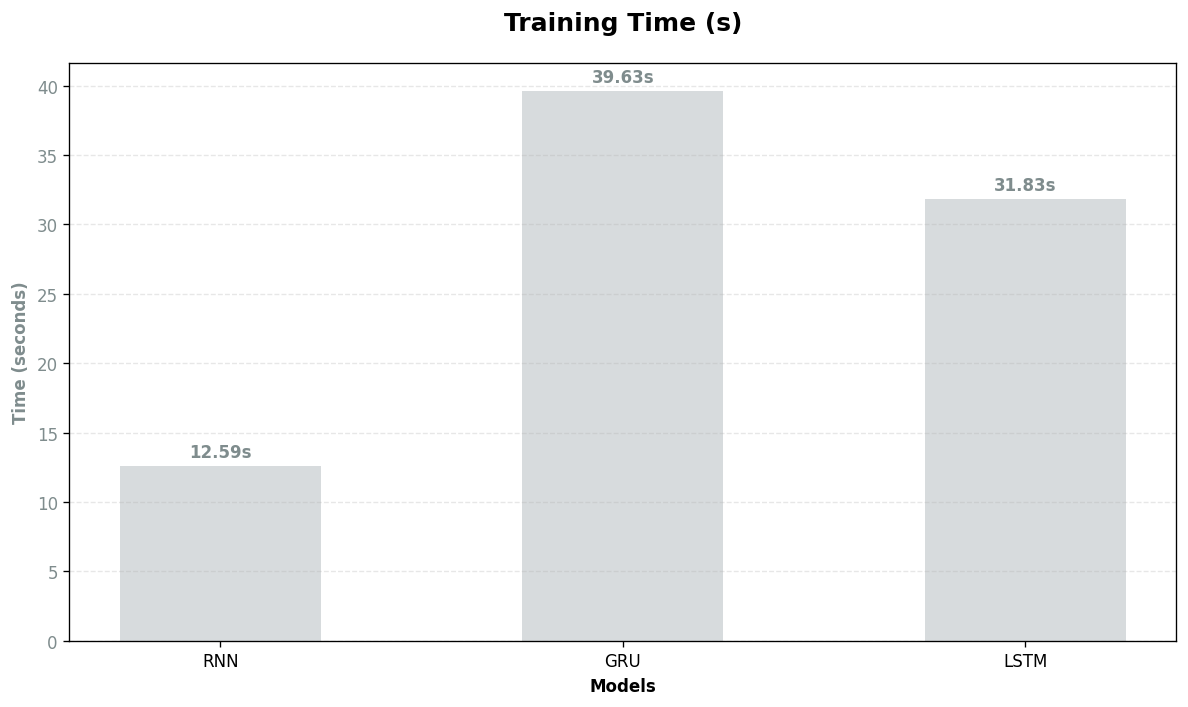

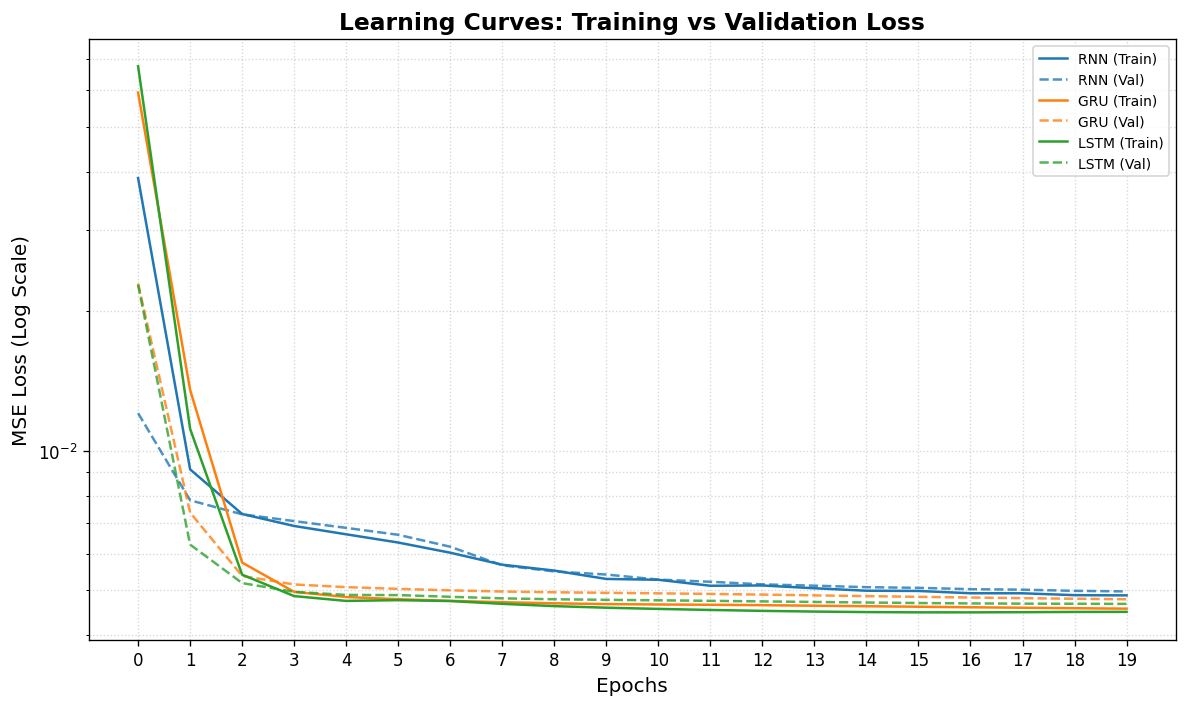

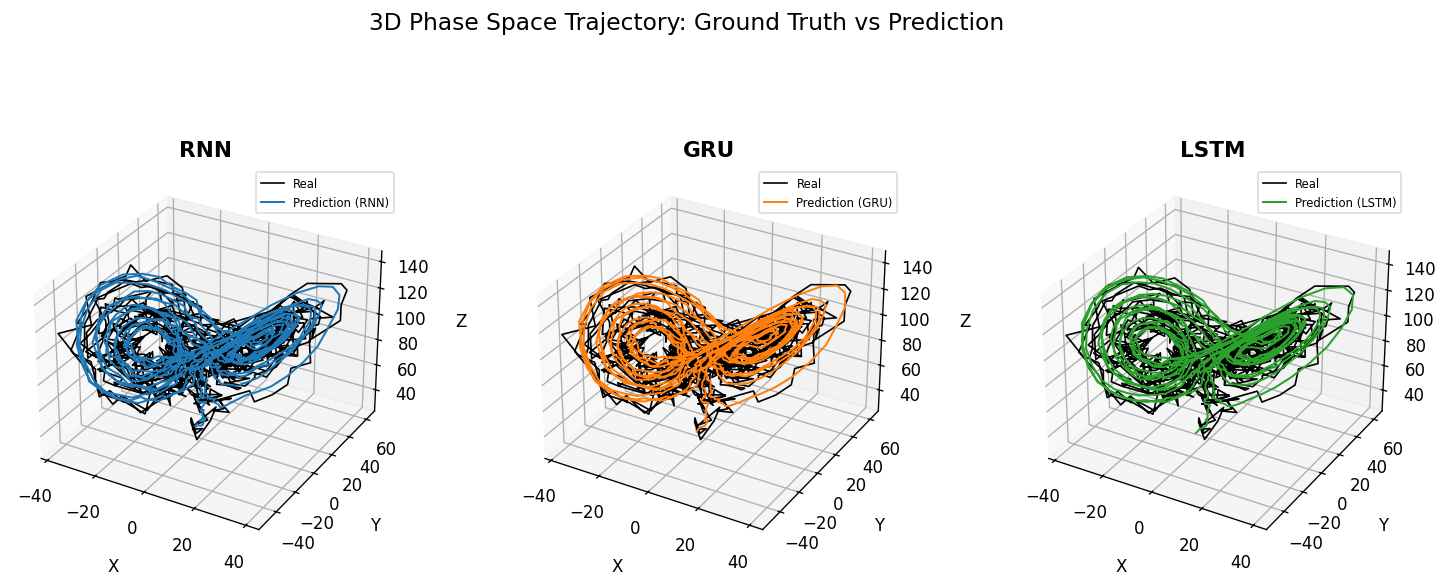

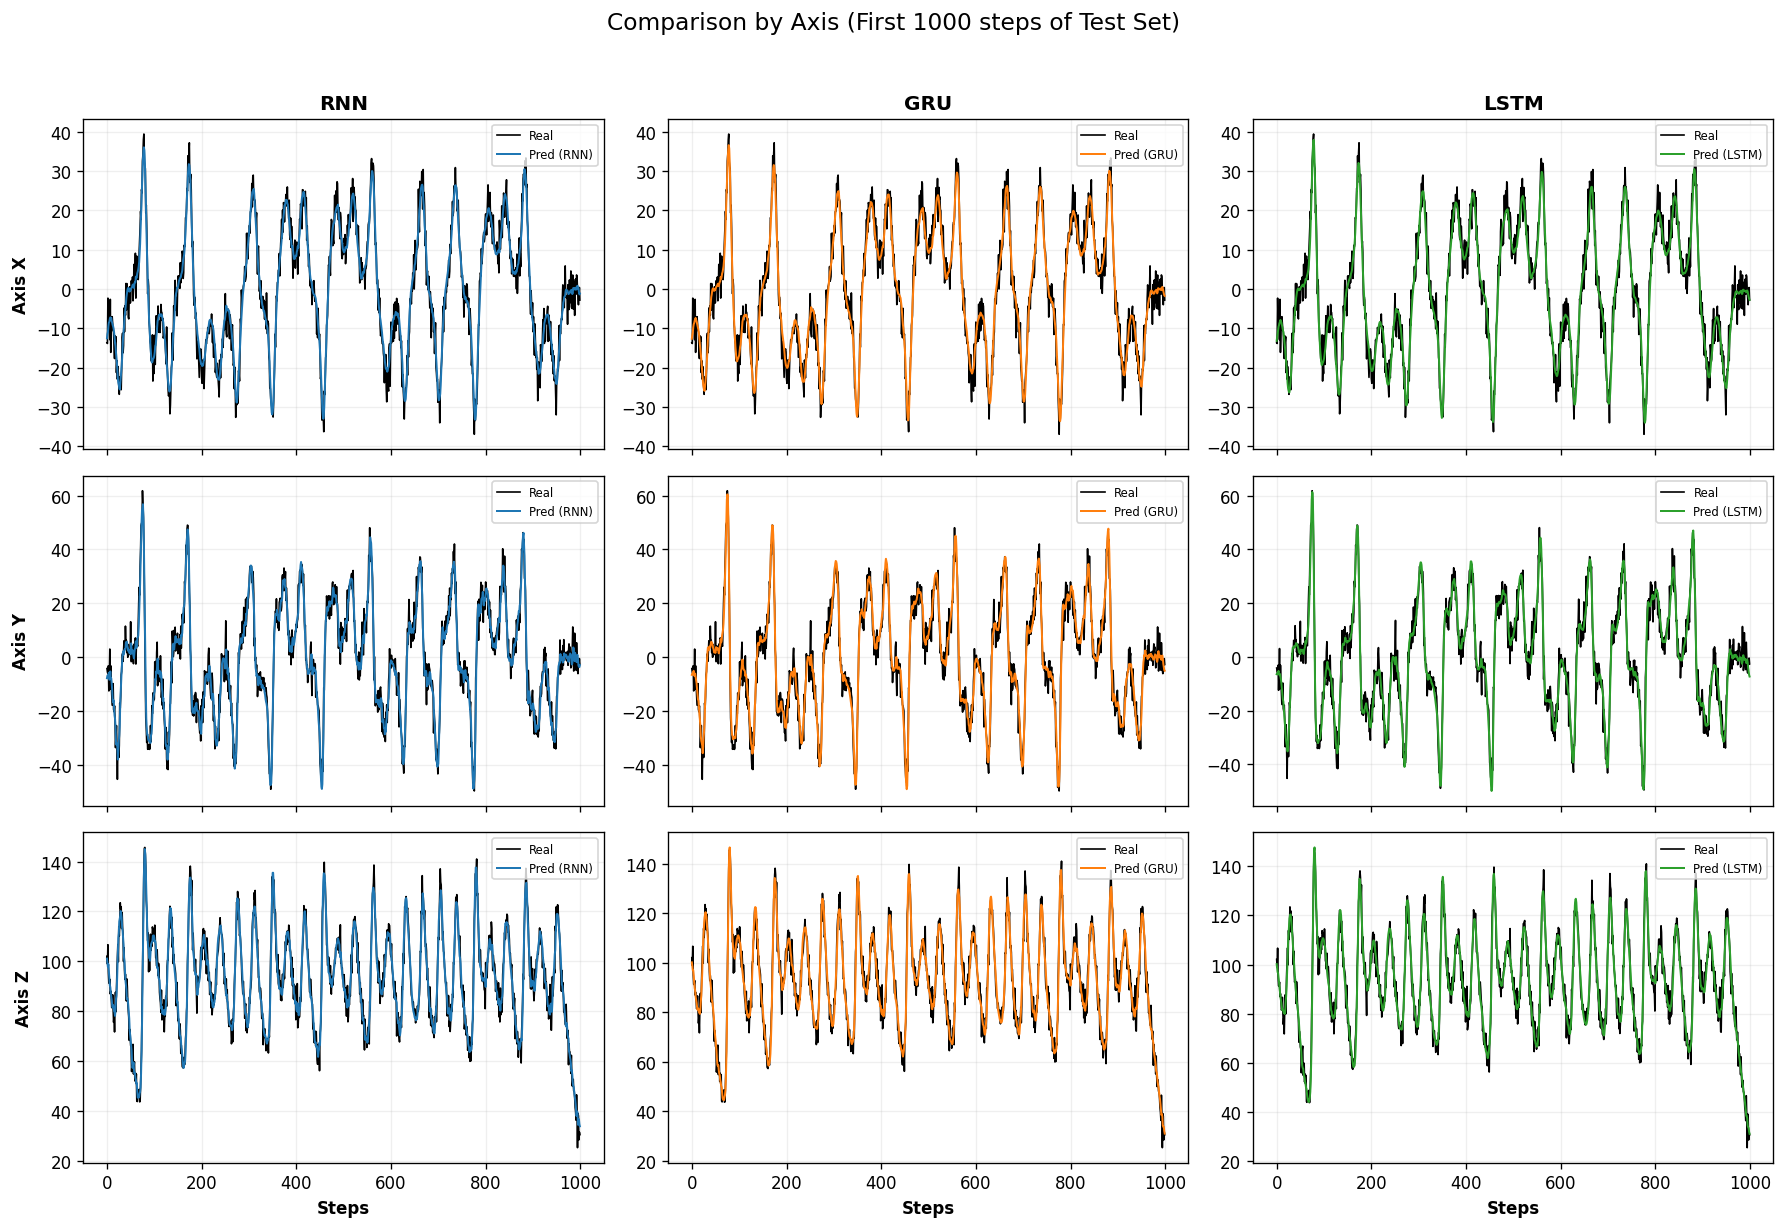

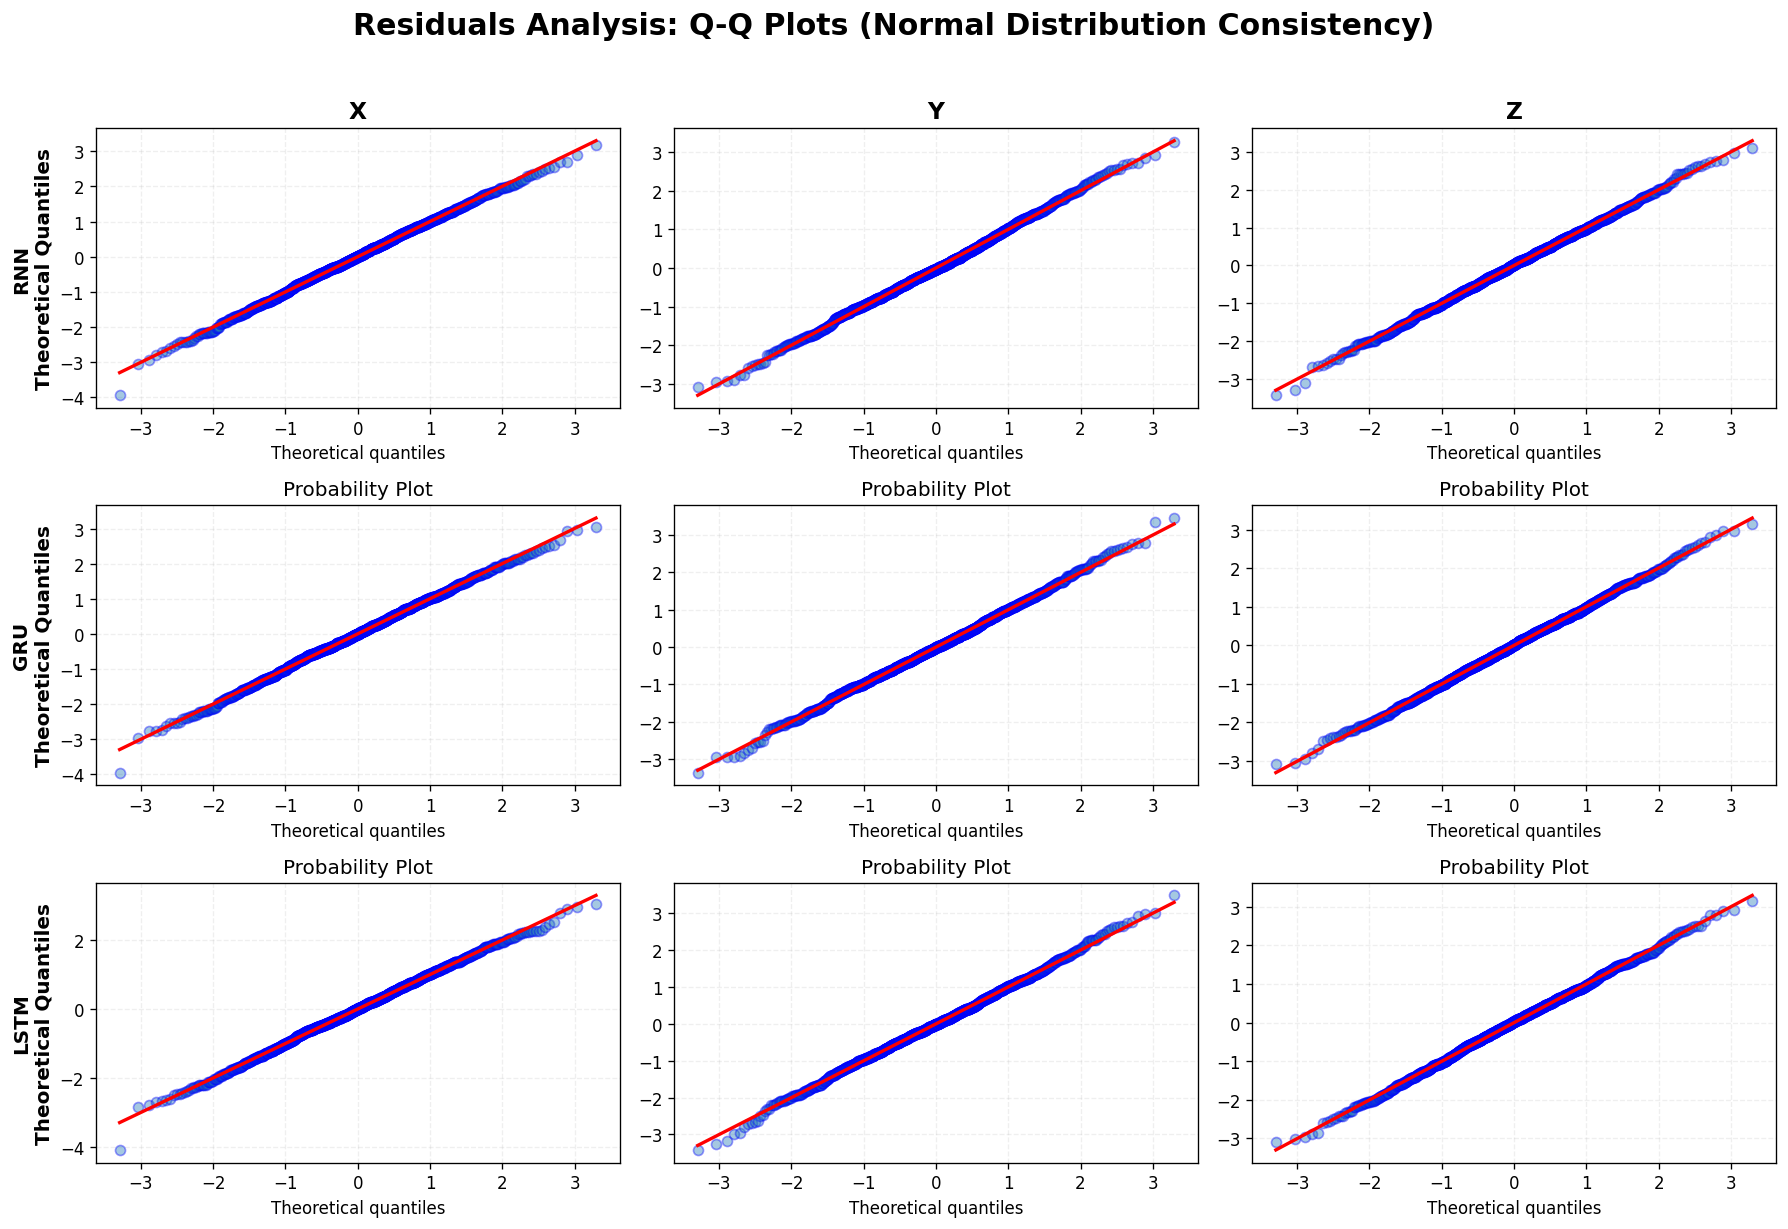

report saved in experiments/20260423_1457_efd11dea/plots/


In [31]:
def run_full_report(exp, logger):
    plot_training_time(exp.records, save_path=f"{logger.path}/plots/training_time.png")
    plot_loss_curves(exp.records, save_path=f"{logger.path}/plots/loss_curves.png")
    plot_3d_comparison_one(exp.records, save_path=f"{logger.path}/plots/3d_trajectories.png", steps=1000)
    plot_models_comparison_by_axis(exp.records, save_path=f"{logger.path}/plots/comparison_by_axis.png", steps=1000)
    plot_qq_matrix(exp.records, save_path=f"{logger.path}/plots/qq_plots.png") 
    logger.save_results(exp)
    print(f"report saved in {logger.path}/plots/")

run_full_report(exp, logger)